# Test pytree


In [6]:
import numpy as np

from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.morphogen_regimes import mr_const
from evoscape.jax import landscape_to_pytree, pytree_to_landscape, wrapped_regime, get_cell_states, _integrate, compute_potentials
from evoscape.landscape_visuals import visualize_landscape

In [7]:
modules = (
    Node(x=-1.0, y=0.0, a=np.array([1.2]), s=np.array([1.0])),
    Node(x=1.0, y=0.0, a=np.array([1.2]), s=np.array([1.0])),
)

landscape = Landscape(
    module_list=modules,
    A0=0.05,
    init_cond=(0.0, 0.0),
    regime=mr_const,
    n_regimes=1,
    morphogen_times=(),
)

dynamic, static = landscape_to_pytree(landscape)
dynamic, static

(LandscapeDynamic(init_cond=Array([0., 0.], dtype=float32), module=ModuleDynamic(x=Array([-1.,  1.], dtype=float32), y=Array([0., 0.], dtype=float32), a=Array([[1.2],
        [1.2]], dtype=float32), s=Array([[1.],
        [1.]], dtype=float32))),
 LandscapeStatic(A0=0.05, x0=Array([0., 0.], dtype=float32), n_regimes=1, regime_id=0, morphogen_times=Array([], shape=(0,), dtype=float32), module=ModuleStatic(J=Array([[[-1.,  0.],
         [ 0., -1.]],
 
        [[-1.,  0.],
         [ 0., -1.]]], dtype=float32), tau=Array([0., 0.], dtype=float32), use_tau=Array([False, False], dtype=bool))))

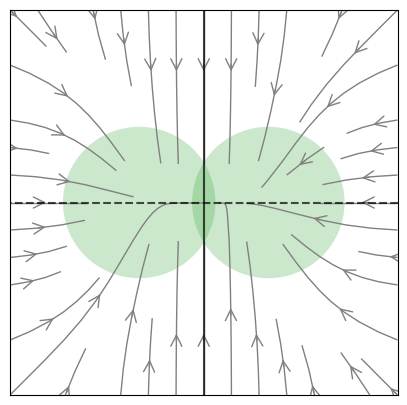

In [8]:
L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')

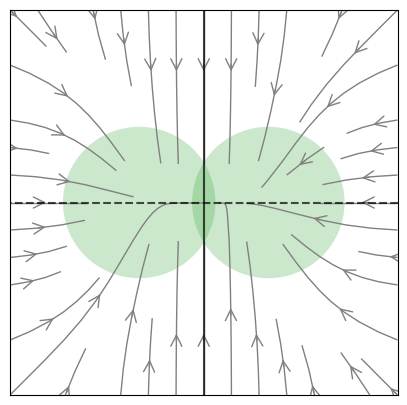

In [9]:
restored = pytree_to_landscape(dynamic, static)

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')

